In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.windows import Window, transform as window_transform

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    cohen_kappa_score
)

PROJECT_ROOT = Path.cwd().parent

data_raw_dir = PROJECT_ROOT / "data" / "raw"
models_dir = PROJECT_ROOT / "models"
outputs_maps_dir = PROJECT_ROOT / "outputs" / "maps"
outputs_reports_dir = PROJECT_ROOT / "outputs" / "reports"

for folder in [models_dir, outputs_maps_dir, outputs_reports_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\aryav\geovision


In [2]:
scene_folder_name = (
    "S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE"
)

base_scene_dir = data_raw_dir / scene_folder_name

if not base_scene_dir.exists():
    print("Available items in data/raw:")
    for item in data_raw_dir.iterdir():
        print("-", item.name)
    raise FileNotFoundError(
        "The scene folder name does not match. Copy the exact .SAFE folder name "
        "from the list printed above."
    )

r10m_candidates = list(base_scene_dir.rglob("R10m"))
r20m_candidates = list(base_scene_dir.rglob("R20m"))

if not r10m_candidates or not r20m_candidates:
    raise FileNotFoundError("Could not find both R10m and R20m inside the L2A product.")

scene_dir_10m = r10m_candidates[0]
scene_dir_20m = r20m_candidates[0]

print("R10m:", scene_dir_10m)
print("R20m:", scene_dir_20m)

R10m: C:\Users\aryav\geovision\data\raw\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\GRANULE\L2A_T44PLU_A039899_20241026T051112\IMG_DATA\R10m
R20m: C:\Users\aryav\geovision\data\raw\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\S2B_MSIL2A_20241026T045819_N0511_R119_T44PLU_20241026T080431.SAFE\GRANULE\L2A_T44PLU_A039899_20241026T051112\IMG_DATA\R20m


In [3]:
def find_band_file(folder, band_name, resolution):
    matches = list(folder.glob(f"*_{band_name}_{resolution}.jp2"))
    if not matches:
        matches = list(folder.glob(f"*{band_name}_{resolution}.jp2"))
    if not matches:
        raise FileNotFoundError(f"Cannot find {band_name} ({resolution}) in {folder}")
    return matches[0]

b2_path = find_band_file(scene_dir_10m, "B02", "10m")
b3_path = find_band_file(scene_dir_10m, "B03", "10m")
b4_path = find_band_file(scene_dir_10m, "B04", "10m")
b8_path = find_band_file(scene_dir_10m, "B08", "10m")

b11_path = find_band_file(scene_dir_20m, "B11", "20m")
b12_path = find_band_file(scene_dir_20m, "B12", "20m")

crop_size = 2000

with rasterio.open(b2_path) as src:
    full_height, full_width = src.height, src.width

    # A central crop usually contains valid mixed land cover for this scene.
    row_start = max(0, full_height // 2 - crop_size // 2)
    col_start = max(0, full_width // 2 - crop_size // 2)

    window = Window(col_start, row_start, crop_size, crop_size)

    b2 = src.read(1, window=window).astype("float32")
    crop_transform = src.window_transform(window)
    crs = src.crs
    profile = src.profile.copy()

def read_10m_crop(path):
    with rasterio.open(path) as src:
        return src.read(1, window=window).astype("float32")

b3 = read_10m_crop(b3_path)
b4 = read_10m_crop(b4_path)
b8 = read_10m_crop(b8_path)

H, W = b2.shape

def read_20m_resampled(path, target_shape, target_transform, target_crs):
    with rasterio.open(path) as src:
        source = src.read(1).astype("float32")
        destination = np.zeros(target_shape, dtype=np.float32)

        reproject(
            source=source,
            destination=destination,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.bilinear
        )

    return destination

b11 = read_20m_resampled(b11_path, (H, W), crop_transform, crs)
b12 = read_20m_resampled(b12_path, (H, W), crop_transform, crs)

print("Crop dimensions:", H, "x", W)
print("Crop pixel count:", H * W)

Crop dimensions: 2000 x 2000
Crop pixel count: 4000000


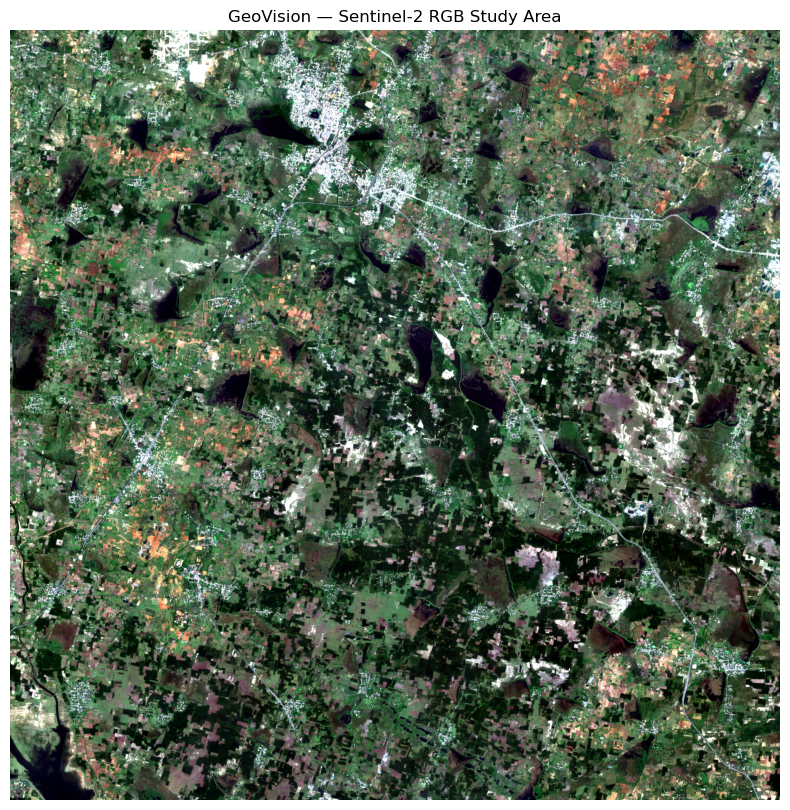

In [4]:
def stretch_to_01(band, low=2, high=98):
    valid = band[band > 0]
    vmin, vmax = np.percentile(valid, [low, high])
    return np.clip((band - vmin) / (vmax - vmin + 1e-6), 0, 1)

rgb = np.dstack([
    stretch_to_01(b4),
    stretch_to_01(b3),
    stretch_to_01(b2)
])

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title("GeoVision — Sentinel-2 RGB Study Area")
plt.axis("off")
plt.show()

In [5]:
eps = 1e-6

ndvi = (b8 - b4) / (b8 + b4 + eps)
ndwi = (b3 - b8) / (b3 + b8 + eps)
ndbi = (b11 - b8) / (b11 + b8 + eps)

valid_mask = (
    (b2 > 0) &
    (b3 > 0) &
    (b4 > 0) &
    (b8 > 0) &
    (b11 > 0) &
    (b12 > 0)
)

features = np.stack(
    [b2, b3, b4, b8, b11, b12, ndvi, ndwi, ndbi],
    axis=-1
).astype("float32")

print("Feature stack:", features.shape)
print("Valid pixels:", int(valid_mask.sum()))

Feature stack: (2000, 2000, 9)
Valid pixels: 3999829


In [6]:
# 255 means "unlabeled/uncertain" and will NOT be used for model training.
seed_labels = np.full((H, W), 255, dtype=np.uint8)

# Water: low NIR, high green-vs-NIR water signal.
water = valid_mask & (ndwi > 0.10) & (ndvi < 0.10)
seed_labels[water] = 3

# Dense forest/tree cover: strong vegetation signal.
forest = valid_mask & (ndvi > 0.55) & ~water
seed_labels[forest] = 2

# Agriculture: moderate healthy vegetation, excluding dense forest.
agriculture = valid_mask & (ndvi > 0.25) & (ndvi <= 0.55) & ~water
seed_labels[agriculture] = 0

# Bare / wasteland: weak vegetation and low built-up signal.
wasteland = (
    valid_mask &
    (ndvi >= -0.05) &
    (ndvi < 0.18) &
    (ndbi < 0.05) &
    ~water
)
seed_labels[wasteland] = 4

# Built-up: higher SWIR relative to NIR, usually lower vegetation.
built_up = (
    valid_mask &
    (ndbi >= 0.05) &
    (ndvi < 0.35) &
    ~water
)
seed_labels[built_up] = 1

# Roads: a very conservative proxy for bright, low-vegetation, built surfaces.
# Sentinel-2 at 10m cannot reliably map small local roads.
roads = (
    valid_mask &
    (b4 > np.percentile(b4[valid_mask], 70)) &
    (ndvi < 0.12) &
    (ndbi >= 0.03) &
    ~water
)
seed_labels[roads] = 5

# Leave only classes that have enough clear seed pixels.
class_names = {
    0: "Agriculture",
    1: "Built-up",
    2: "Forest",
    3: "Water",
    4: "Wasteland",
    5: "Roads"
}

seed_ids, seed_counts = np.unique(seed_labels[seed_labels != 255], return_counts=True)

seed_summary = pd.DataFrame({
    "class_id": seed_ids,
    "class_name": [class_names[int(i)] for i in seed_ids],
    "seed_pixels": seed_counts
})

seed_summary

,class_id,class_name,seed_pixels
0,0,Agriculture,2548876
1,1,Built-up,311308
2,2,Forest,646544
3,3,Water,11877
4,4,Wasteland,208003
5,5,Roads,62914


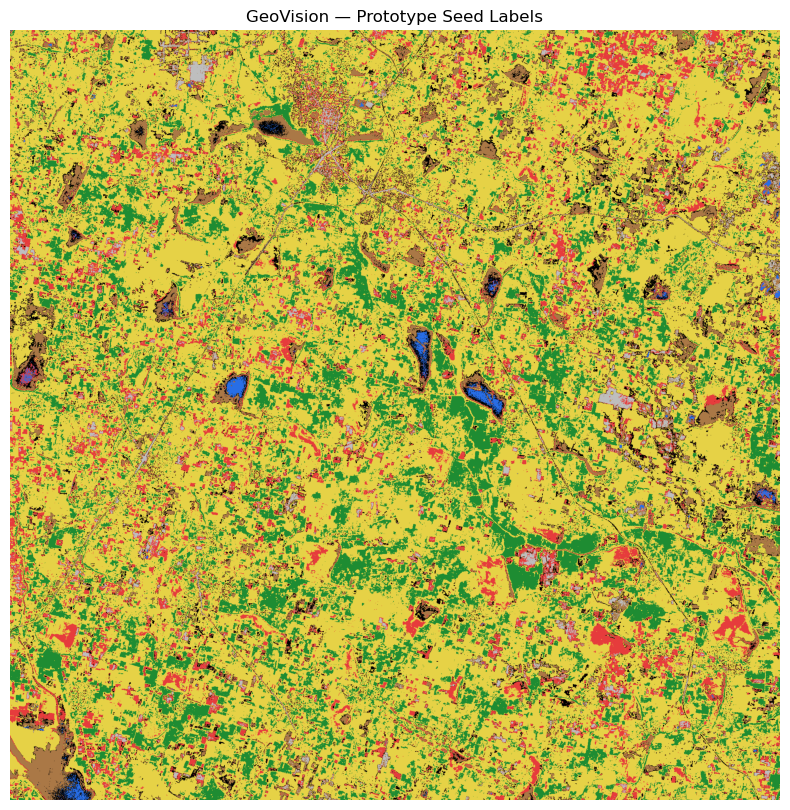

In [7]:
colour_map = {
    0: [230, 210, 70],   # Agriculture - yellow
    1: [230, 60, 60],    # Built-up - red
    2: [30, 140, 50],    # Forest - green
    3: [40, 110, 230],   # Water - blue
    4: [170, 120, 70],   # Wasteland - brown
    5: [190, 190, 190],  # Roads - gray
    255: [0, 0, 0]       # Uncertain - black
}

seed_rgb = np.zeros((H, W, 3), dtype=np.uint8)

for class_id, colour in colour_map.items():
    seed_rgb[seed_labels == class_id] = colour

plt.figure(figsize=(10, 10))
plt.imshow(seed_rgb)
plt.title("GeoVision — Prototype Seed Labels")
plt.axis("off")
plt.show()

In [8]:
rng = np.random.default_rng(42)

X_all = features.reshape(-1, features.shape[-1])
y_all = seed_labels.reshape(-1)

valid_training = y_all != 255
X_seed = X_all[valid_training]
y_seed = y_all[valid_training]

available_classes, available_counts = np.unique(y_seed, return_counts=True)

print("Available seed classes:")
for class_id, count in zip(available_classes, available_counts):
    print(f"{int(class_id)} - {class_names[int(class_id)]}: {count:,} pixels")

# Use equal count per class, capped to avoid excessive memory use.
min_class_count = available_counts.min()
samples_per_class = min(4000, min_class_count)

if samples_per_class < 100:
    raise ValueError(
        "At least one class has fewer than 100 usable seed pixels. "
        "Show me the seed_summary output and we will adjust thresholds."
    )

sample_indices = []

for class_id in available_classes:
    class_indices = np.where(y_seed == class_id)[0]
    chosen = rng.choice(class_indices, size=samples_per_class, replace=False)
    sample_indices.append(chosen)

sample_indices = np.concatenate(sample_indices)

X_sample = X_seed[sample_indices]
y_sample = y_seed[sample_indices]

print("\nBalanced dataset shape:", X_sample.shape)
print("Samples per class:", samples_per_class)

Available seed classes:
0 - Agriculture: 2,548,876 pixels
1 - Built-up: 311,308 pixels
2 - Forest: 646,544 pixels
3 - Water: 11,877 pixels
4 - Wasteland: 208,003 pixels
5 - Roads: 62,914 pixels

Balanced dataset shape: (24000, 9)
Samples per class: 4000


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.20,
    random_state=42,
    stratify=y_sample
)

rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=24,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

overall_accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

report_dict = classification_report(
    y_test,
    y_pred,
    labels=list(range(6)),
    target_names=[class_names[i] for i in range(6)],
    output_dict=True,
    zero_division=0
)

print("Overall accuracy:", round(overall_accuracy, 4))
print("Kappa score:", round(kappa, 4))
print()
print(classification_report(
    y_test,
    y_pred,
    labels=list(range(6)),
    target_names=[class_names[i] for i in range(6)],
    zero_division=0
))

Overall accuracy: 1.0
Kappa score: 1.0

              precision    recall  f1-score   support

 Agriculture       1.00      1.00      1.00       800
    Built-up       1.00      1.00      1.00       800
      Forest       1.00      1.00      1.00       800
       Water       1.00      1.00      1.00       800
   Wasteland       1.00      1.00      1.00       800
       Roads       1.00      1.00      1.00       800

    accuracy                           1.00      4800
   macro avg       1.00      1.00      1.00      4800
weighted avg       1.00      1.00      1.00      4800



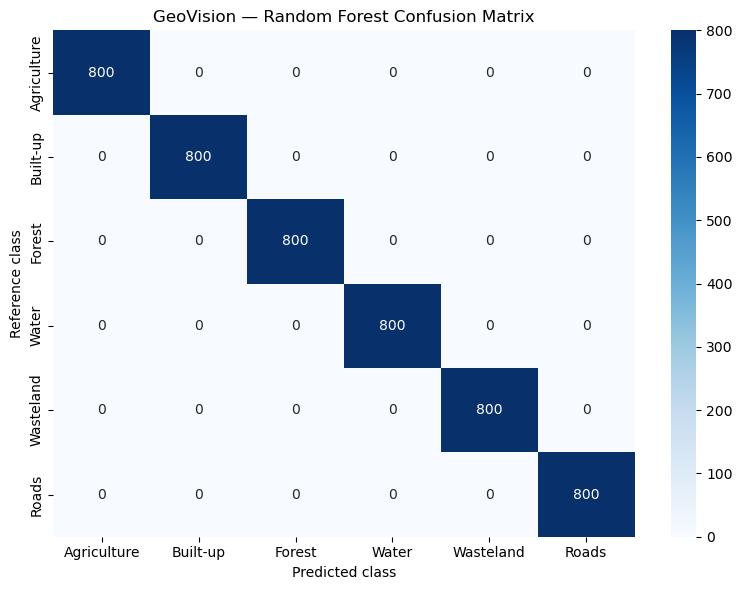

Saved: C:\Users\aryav\geovision\outputs\reports\confusion_matrix.png
Saved: C:\Users\aryav\geovision\outputs\reports\classification_report.csv
Saved: C:\Users\aryav\geovision\outputs\reports\model_metrics.json


,class_id,class_name,precision,recall,f1_score,support
0,0,Agriculture,1.0,1.0,1.0,800
1,1,Built-up,1.0,1.0,1.0,800
2,2,Forest,1.0,1.0,1.0,800
3,3,Water,1.0,1.0,1.0,800
4,4,Wasteland,1.0,1.0,1.0,800
5,5,Roads,1.0,1.0,1.0,800


In [10]:
labels = list(range(6))

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[class_names[i] for i in labels],
    yticklabels=[class_names[i] for i in labels]
)
plt.xlabel("Predicted class")
plt.ylabel("Reference class")
plt.title("GeoVision — Random Forest Confusion Matrix")
plt.tight_layout()

confusion_path = outputs_reports_dir / "confusion_matrix.png"
plt.savefig(confusion_path, dpi=200, bbox_inches="tight")
plt.show()

metric_rows = []

for class_id in labels:
    class_label = class_names[class_id]
    values = report_dict.get(class_label, {})
    metric_rows.append({
        "class_id": class_id,
        "class_name": class_label,
        "precision": round(values.get("precision", 0), 4),
        "recall": round(values.get("recall", 0), 4),
        "f1_score": round(values.get("f1-score", 0), 4),
        "support": int(values.get("support", 0))
    })

metrics_df = pd.DataFrame(metric_rows)

metrics_csv_path = outputs_reports_dir / "classification_report.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

summary_metrics = {
    "model": "RandomForestClassifier",
    "data_source": "Sentinel-2 Level-2A",
    "classes": class_names,
    "overall_accuracy": round(float(overall_accuracy), 4),
    "kappa_score": round(float(kappa), 4),
    "training_note": (
        "Prototype model trained from transparent spectral-rule seed labels. "
        "For operational use, replace seed labels with expert ground-truth polygons."
    )
}

metrics_json_path = outputs_reports_dir / "model_metrics.json"

with open(metrics_json_path, "w", encoding="utf-8") as file:
    json.dump(summary_metrics, file, indent=4)

print("Saved:", confusion_path)
print("Saved:", metrics_csv_path)
print("Saved:", metrics_json_path)

metrics_df

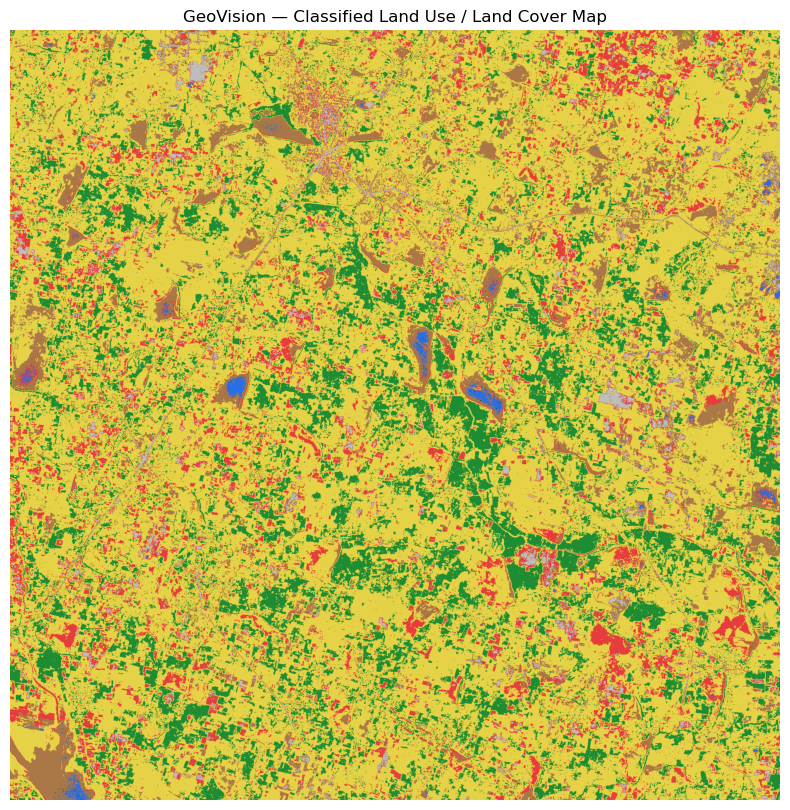

In [11]:
# Classify only pixels with usable Sentinel-2 data.
classification = np.full((H, W), 255, dtype=np.uint8)

X_crop = features.reshape(-1, features.shape[-1])
valid_flat = valid_mask.reshape(-1)

classification_flat = classification.reshape(-1)
classification_flat[valid_flat] = rf.predict(X_crop[valid_flat]).astype(np.uint8)

classification = classification_flat.reshape(H, W)

classified_rgb = np.zeros((H, W, 3), dtype=np.uint8)

for class_id, colour in colour_map.items():
    classified_rgb[classification == class_id] = colour

plt.figure(figsize=(10, 10))
plt.imshow(classified_rgb)
plt.title("GeoVision — Classified Land Use / Land Cover Map")
plt.axis("off")
plt.show()

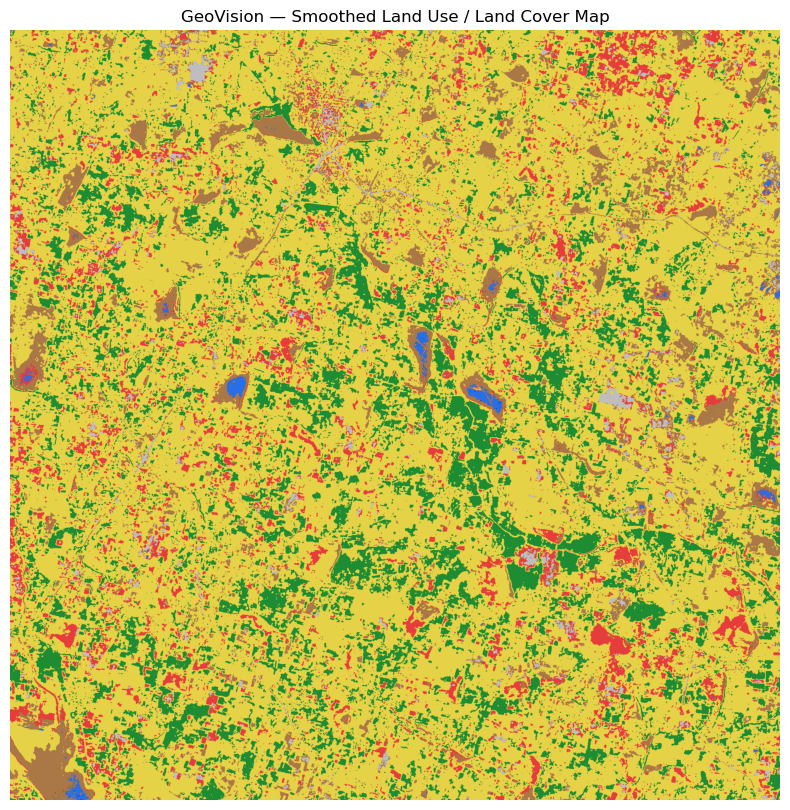

In [12]:
from scipy.ndimage import generic_filter

def majority_filter(values):
    values = values.astype(np.uint8)

    # Ignore nodata values (255).
    valid_values = values[values != 255]

    if valid_values.size == 0:
        return 255

    return np.bincount(valid_values, minlength=256).argmax()

# Apply a 3x3 moving-window majority filter.
# This removes isolated pixel noise while preserving broader regions.
classification_smooth = generic_filter(
    classification,
    function=majority_filter,
    size=3,
    mode="nearest"
).astype(np.uint8)

# Restore nodata pixels.
classification_smooth[~valid_mask] = 255

classified_smooth_rgb = np.zeros((H, W, 3), dtype=np.uint8)

for class_id, colour in colour_map.items():
    classified_smooth_rgb[classification_smooth == class_id] = colour

plt.figure(figsize=(10, 10))
plt.imshow(classified_smooth_rgb)
plt.title("GeoVision — Smoothed Land Use / Land Cover Map")
plt.axis("off")
plt.show()

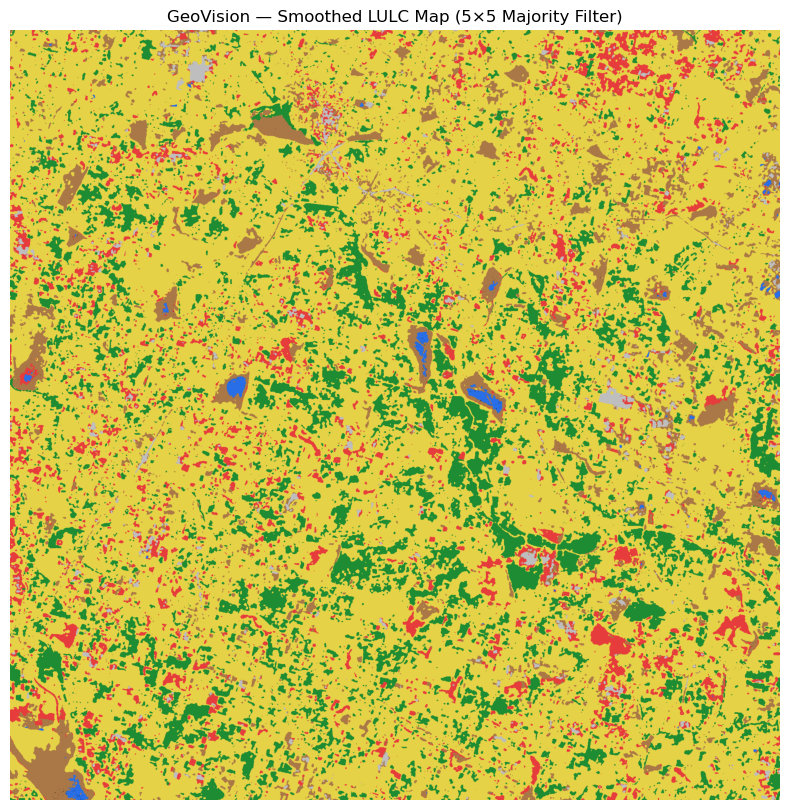

In [13]:
classification_smooth_5 = generic_filter(
    classification,
    function=majority_filter,
    size=5,
    mode="nearest"
).astype(np.uint8)

# Keep no-data pixels as no-data.
classification_smooth_5[~valid_mask] = 255

classified_smooth_5_rgb = np.zeros((H, W, 3), dtype=np.uint8)

for class_id, colour in colour_map.items():
    classified_smooth_5_rgb[classification_smooth_5 == class_id] = colour

plt.figure(figsize=(10, 10))
plt.imshow(classified_smooth_5_rgb)
plt.title("GeoVision — Smoothed LULC Map (5×5 Majority Filter)")
plt.axis("off")
plt.show()

In [15]:
# Set the 5×5 smoothed result as the official final prototype output.
final_classification = classification_smooth_5
final_classified_rgb = classified_smooth_5_rgb

print("Final classification shape:", final_classification.shape)
print("Final RGB map shape:", final_classified_rgb.shape)

Final classification shape: (2000, 2000)
Final RGB map shape: (2000, 2000, 3)


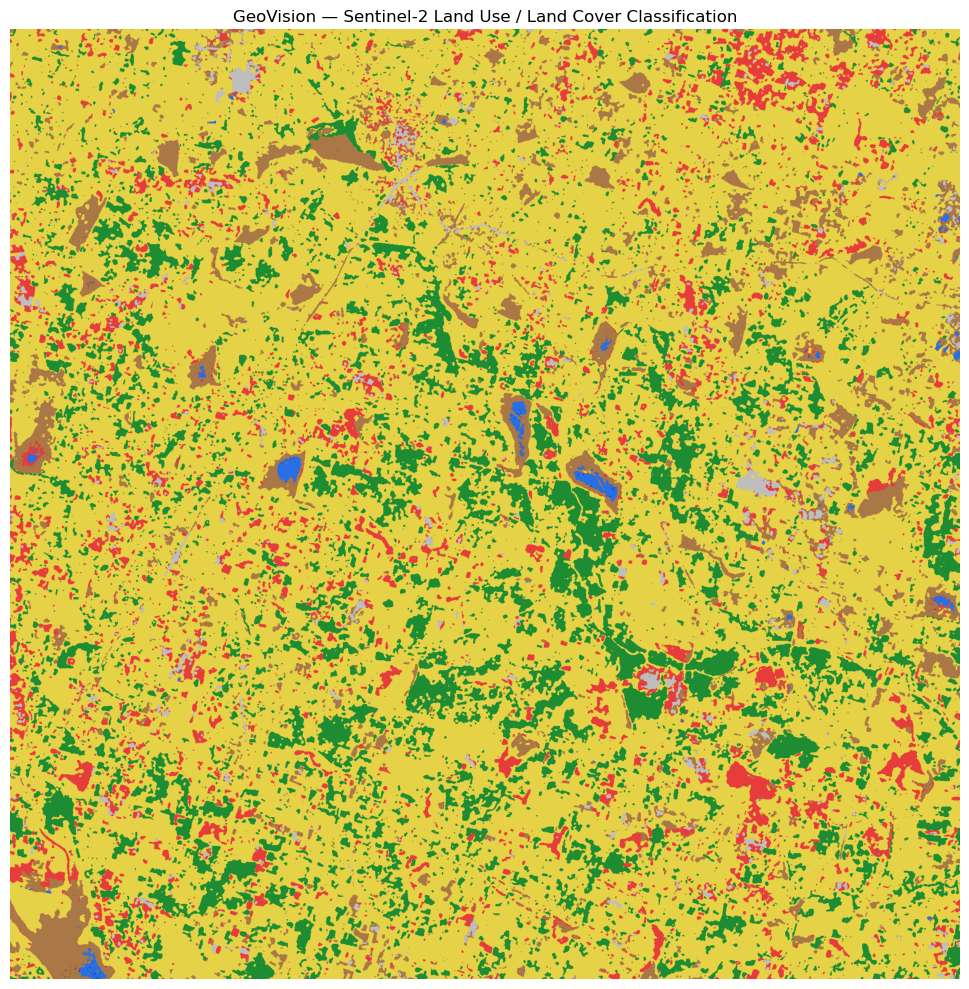

GeoTIFF saved: C:\Users\aryav\geovision\outputs\maps\geovision_lulc_classified.tif
PNG saved: C:\Users\aryav\geovision\outputs\maps\geovision_lulc_classified.png
Area statistics saved: C:\Users\aryav\geovision\outputs\reports\land_cover_area_statistics.csv


,class_id,class_name,pixel_count,area_hectares,area_km2,percentage
0,0,Agriculture,2886011,28860.11,288.601,72.15
1,1,Built-up,254026,2540.26,25.403,6.35
2,2,Forest,551781,5517.81,55.178,13.80
3,3,Water,11300,113.00,1.130,0.28
4,4,Wasteland,248296,2482.96,24.830,6.21
5,5,Roads,48415,484.15,4.841,1.21


In [16]:
map_path = outputs_maps_dir / "geovision_lulc_classified.tif"

output_profile = profile.copy()
output_profile.update(
    driver="GTiff",
    height=H,
    width=W,
    count=1,
    dtype="uint8",
    crs=crs,
    transform=crop_transform,
    compress="lzw",
    nodata=255
)

with rasterio.open(map_path, "w", **output_profile) as dst:
    dst.write(final_classification, 1)

pixel_area_m2 = abs(crop_transform.a * crop_transform.e)
classified_pixels = int((final_classification != 255).sum())

area_rows = []

for class_id in range(6):
    pixel_count = int((final_classification == class_id).sum())
    area_m2 = pixel_count * pixel_area_m2
    area_ha = area_m2 / 10_000
    area_km2 = area_m2 / 1_000_000
    percentage = pixel_count / classified_pixels * 100 if classified_pixels else 0

    area_rows.append({
        "class_id": class_id,
        "class_name": class_names[class_id],
        "pixel_count": pixel_count,
        "area_hectares": round(area_ha, 2),
        "area_km2": round(area_km2, 3),
        "percentage": round(percentage, 2)
    })

area_df = pd.DataFrame(area_rows)

area_csv_path = outputs_reports_dir / "land_cover_area_statistics.csv"
area_df.to_csv(area_csv_path, index=False)

map_png_path = outputs_maps_dir / "geovision_lulc_classified.png"

plt.figure(figsize=(11, 10))
plt.imshow(final_classified_rgb)
plt.title("GeoVision — Sentinel-2 Land Use / Land Cover Classification")
plt.axis("off")
plt.tight_layout()
plt.savefig(map_png_path, dpi=250, bbox_inches="tight")
plt.show()

print("GeoTIFF saved:", map_path)
print("PNG saved:", map_png_path)
print("Area statistics saved:", area_csv_path)

area_df